<a href="https://colab.research.google.com/github/lodenaq/SUNY-Canton-Projects/blob/main/Copy_of_Mobile_Crowd_Snesing_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Part 1: Data Preparation
# =========================

# Import core data science libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning Tools
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
from sklearn.svm import SVC
from sklearn.linear_model import Perceptron
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

In [ ]:
# Data Loading and Preprocessing

from google.colab import drive
drive.mount('/content/drive')

# Load training and test datasets
train_path = '/content/drive/MyDrive/irrigation_trainingset.csv'
test_path = '/content/drive/MyDrive/irrigation_testset.csv'

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

# Assume last column is the label; adjust if needed
X_train = train_df.iloc[:, :-1].values
y_train = train_df.iloc[:, -1].values

X_test = test_df.iloc[:, :-1].values
y_test = test_df.iloc[:, -1].values

# Normalize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data shapes:")
print("X_train:", X_train_scaled.shape, "y_train:", y_train.shape)
print("X_test:", X_test_scaled.shape, "y_test:", y_test.shape)

Mounted at /content/drive
Data shapes:
X_train: (560, 4) y_train: (560,)
X_test: (240, 4) y_test: (240,)


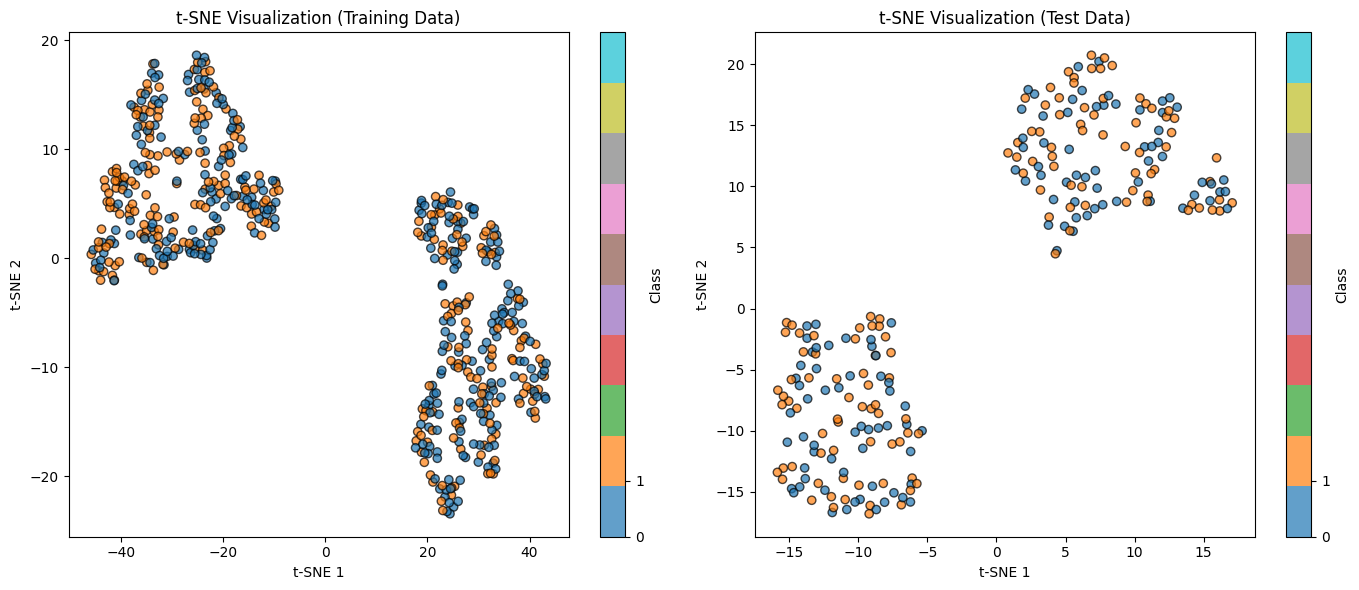

In [ ]:
# t-SNE Data Visualization
# ==================================

def plot_tsne(X, y, title, ax):
    tsne = TSNE(n_components=2, random_state=42, perplexity=30, learning_rate=200)
    X_embedded = tsne.fit_transform(X)

    # FIX: Convert y to integers or strings so matplotlib treats them as
    # distinct categorical classes instead of a single continuous numeric range
    y_categorical = y.astype(int)

    # FIX: Use 'c=y_categorical' and added 'vmax'/'vmin' boundaries to force discrete colors
    scatter = ax.scatter(X_embedded[:, 0], X_embedded[:, 1],
                         c=y_categorical, cmap="tab10", alpha=0.7, edgecolor="k",
                         vmin=0, vmax=9) # tab10 has 10 color slots (0-9)

    ax.set_title(title)
    ax.set_xlabel("t-SNE 1")
    ax.set_ylabel("t-SNE 2")
    return scatter

# Create a figure with 2 separate side-by-side plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

scatter1 = plot_tsne(X_train_scaled, y_train, "t-SNE Visualization (Training Data)", ax1)
# FIX: Use 'ticks' on the colorbar to show clear, discrete class labels instead of a decimal scale
classes = np.unique(y_train).astype(int)
fig.colorbar(scatter1, ax=ax1, label="Class", ticks=classes)

scatter2 = plot_tsne(X_test_scaled, y_test, "t-SNE Visualization (Test Data)", ax2)
fig.colorbar(scatter2, ax=ax2, label="Class", ticks=classes)

plt.tight_layout()
plt.show()

In [ ]:
# Part 3: Model Development
# =========================

models = {
    "SVM": SVC(kernel="rbf", C=1.0, gamma="scale", random_state=42),
    "Perceptron": Perceptron(random_state=42, max_iter=1000),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Random Forest": RandomForestClassifier(random_state=42)
}
def train_and_report(model_name, model, X_tr, y_tr):
    model.fit(X_tr, y_tr)
    y_pred_tr = model.predict(X_tr)

    acc = accuracy_score(y_tr, y_pred_tr)
    prec = precision_score(y_tr, y_pred_tr, average="weighted", zero_division=0)
    rec = recall_score(y_tr, y_pred_tr, average="weighted", zero_division=0)
    f1 = f1_score(y_tr, y_pred_tr, average="weighted", zero_division=0)

    # 1. Calculate confusion matrix
    cm = confusion_matrix(y_tr, y_pred_tr)

    # 2. Calculate detailed classification report
    report = classification_report(y_tr, y_pred_tr, zero_division=0)

    # 3. Print the exact structure matching your image
    print(f"\n=== Training Performance: {model_name} ===")
    print("Confusion Matrix:\n", cm)
    print("Accuracy :", acc)
    print("Precision:", prec)
    print("Recall   :", rec)
    print("F1-score :", f1)
    print("\nClassification Report:\n", report)

    return model
#def train_and_report(model_name, model, X_tr, y_tr):
 #   model.fit(X_tr, y_tr)
  #  y_pred_tr = model.predict(X_tr)

   # acc = accuracy_score(y_tr, y_pred_tr)
    #prec = precision_score(y_tr, y_pred_tr, average="weighted", zero_division=0)
   # rec = recall_score(y_tr, y_pred_tr, average="weighted", zero_division=0)
   # f1 = f1_score(y_tr, y_pred_tr, average="weighted", zero_division=0)
   # cm = confusion_matrix(y_tr, y_pred_tr) # Added this line to calculate cm

    #print(f"\n=== Training Performance: {model_name} ===")
    #print("Accuracy :", acc)
    #print("Precision:", prec)
    #print("Recall   :", rec)
    #print("F1-score :", f1)

    # --- ADD THESE LINES TO PRINT THE MATRIX ---
    #print("Confusion Matrix:\n", cm)

    #return model

trained_models = {}
for name, model in models.items():
    trained_models[name] = train_and_report(name, model, X_train_scaled, y_train)


=== Training Performance: SVM ===
Confusion Matrix:
 [[250  42]
 [179  89]]
Accuracy : 0.6053571428571428
Precision: 0.6289991179304156
Recall   : 0.6053571428571428
F1-score : 0.5750989818512995

Classification Report:
               precision    recall  f1-score   support

           0       0.58      0.86      0.69       292
           1       0.68      0.33      0.45       268

    accuracy                           0.61       560
   macro avg       0.63      0.59      0.57       560
weighted avg       0.63      0.61      0.58       560


=== Training Performance: Perceptron ===
Confusion Matrix:
 [[223  69]
 [181  87]]
Accuracy : 0.5535714285714286
Precision: 0.5547138505059297
Recall   : 0.5535714285714286
F1-score : 0.5305287046503703

Classification Report:
               precision    recall  f1-score   support

           0       0.55      0.76      0.64       292
           1       0.56      0.32      0.41       268

    accuracy                           0.55       560
   m

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# We define the models right here before evaluating them
models = {
    'Perceptron': Perceptron(class_weight='balanced', random_state=42),
    'KNN': KNeighborsClassifier(weights='distance'),
    'SVM': SVC(class_weight='balanced', random_state=42),
    'Random Forest': RandomForestClassifier(class_weight='balanced', random_state=42)
}

In [ ]:
# Model Evaluation
# =========================

#def evaluate_model(model_name, model, X_te, y_te):
    # Generate predictions on the test/evaluation data
    #y_pred_te = model.predict(X_te)

    # Compute metrics
    #acc = accuracy_score(y_te, y_pred_te)
    #prec = precision_score(y_te, y_pred_te, average="weighted", zero_division=0)
    #rec = recall_score(y_te, y_pred_te, average="weighted", zero_division=0)
    #f1 = f1_score(y_te, y_pred_te, average="weighted", zero_division=0)

    # Print block formatted exactly like your clean summary example
    #print(f"\n=== Test Performance: {model_name} ===")
    #print("Accuracy :", acc)
    #print("Precision:", prec)
    #print("Recall   :", rec)
    #print("F1-score :", f1)

    #return model
def evaluate_model(model_name, model, X_te, y_te):
    y_pred = model.predict(X_te)

    cm = confusion_matrix(y_te, y_pred)
    acc = accuracy_score(y_te, y_pred)
    prec = precision_score(y_te, y_pred, average="weighted", zero_division=0)
    rec = recall_score(y_te, y_pred, average="weighted", zero_division=0)
    f1 = f1_score(y_te, y_pred, average="weighted", zero_division=0)

    print(f"\n=== Test Performance: {model_name} ===")
    print("Confusion Matrix:\n", cm)
    print("Accuracy :", acc)
    print("Precision:", prec)
    print("Recall   :", rec)
    print("F1-score :", f1)
    print("\nClassification Report:\n", classification_report(y_te, y_pred, zero_division=0))

    return acc, prec, rec, f1

trained_models = {}
for name, model in models.items():
    # UPDATE THIS LINE to use X_train_scaled:
    model.fit(X_train_scaled, y_train)
    trained_models[name] = model

results = {}
for name, model in trained_models.items():
    results[name] = evaluate_model(name, model, X_test_scaled, y_test)


=== Test Performance: Perceptron ===
Confusion Matrix:
 [[23 92]
 [28 97]]
Accuracy : 0.5
Precision: 0.4834007677144932
Recall   : 0.5
F1-score : 0.4545698718440641

Classification Report:
               precision    recall  f1-score   support

           0       0.45      0.20      0.28       115
           1       0.51      0.78      0.62       125

    accuracy                           0.50       240
   macro avg       0.48      0.49      0.45       240
weighted avg       0.48      0.50      0.45       240


=== Test Performance: KNN ===
Confusion Matrix:
 [[62 53]
 [66 59]]
Accuracy : 0.5041666666666667
Precision: 0.5064639136904762
Recall   : 0.5041666666666667
F1-score : 0.5038308937160321

Classification Report:
               precision    recall  f1-score   support

           0       0.48      0.54      0.51       115
           1       0.53      0.47      0.50       125

    accuracy                           0.50       240
   macro avg       0.51      0.51      0.50       

In [ ]:
# Hyperparameter Tuning
# =============================

from sklearn.model_selection import GridSearchCV

# Define hyperparameter grids for each model
param_grids = {
    "Perceptron": {
        "alpha": [0.0001, 0.001, 0.01, 0.1],
        "max_iter": [1000, 2000]
    },
    "KNN": {
        "n_neighbors": [3, 5, 7, 9],
        "metric": ["euclidean", "manhattan"]
    },
    "SVM": {
        "C": [0.1, 1, 10, 100],
        "gamma": ["scale", "auto", 0.01, 0.1],
        "kernel": ["rbf", "linear"]
    },
    "Random Forest": {
        "n_estimators": [100, 200, 300],
        "max_depth": [None, 10, 20, 30],
        "min_samples_split": [2, 5, 10]
    }
}

tuned_models = {}
tuning_results = {}

print("Starting Hyperparameter Tuning...")

# Loop through each model to find the best settings using 5-fold Cross-Validation
for name, model in models.items():
    print(f"\nTuning {name}...")

    # Setup the grid search
    grid_search = GridSearchCV(
        estimator=model,
        param_grid=param_grids[name],
        cv=5,
        scoring="accuracy",
        n_jobs=-1
    )

    # Fit on training data
    grid_search.fit(X_train_scaled, y_train)

    # Save the best estimator and parameters
    tuned_models[name] = grid_search.best_estimator_

    print(f"Best Parameters for {name}: {grid_search.best_params_}")
    print(f"Best Validation Accuracy: {grid_search.best_score_:.4f}")

# Evaluate Best Models on Test Data
# ========================================

print("\n\n==========================================")
print("EVALUATING OPTIMIZED MODELS ON TEST DATA")
print("==========================================")

tuned_test_results = {}
for name, model in tuned_models.items():
    tuned_test_results[name] = evaluate_model(name, model, X_test_scaled, y_test)

Starting Hyperparameter Tuning...

Tuning Perceptron...
Best Parameters for Perceptron: {'alpha': 0.0001, 'max_iter': 1000}
Best Validation Accuracy: 0.4750

Tuning KNN...
Best Parameters for KNN: {'metric': 'euclidean', 'n_neighbors': 3}
Best Validation Accuracy: 0.5357

Tuning SVM...
Best Parameters for SVM: {'C': 0.1, 'gamma': 'auto', 'kernel': 'rbf'}
Best Validation Accuracy: 0.5696

Tuning Random Forest...
Best Parameters for Random Forest: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 100}
Best Validation Accuracy: 0.5607


EVALUATING OPTIMIZED MODELS ON TEST DATA

=== Test Performance: Perceptron ===
Confusion Matrix:
 [[23 92]
 [28 97]]
Accuracy : 0.5
Precision: 0.4834007677144932
Recall   : 0.5
F1-score : 0.4545698718440641

Classification Report:
               precision    recall  f1-score   support

           0       0.45      0.20      0.28       115
           1       0.51      0.78      0.62       125

    accuracy                           0.50       240
  

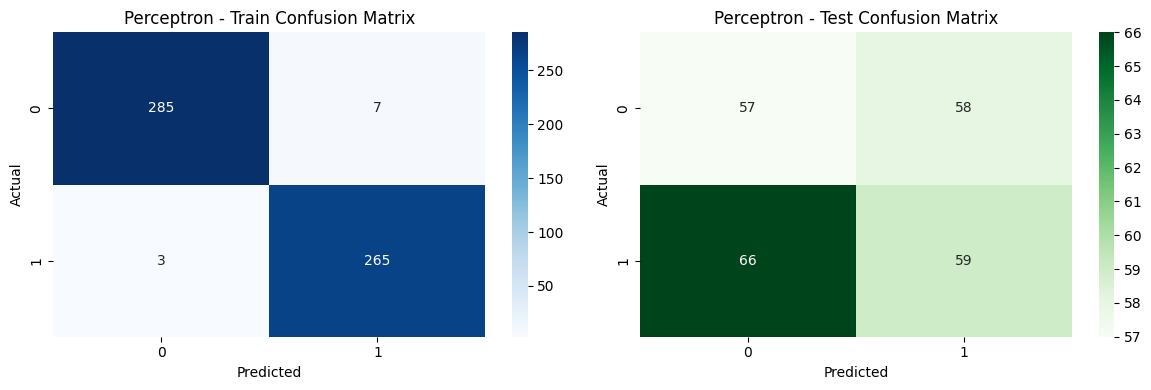

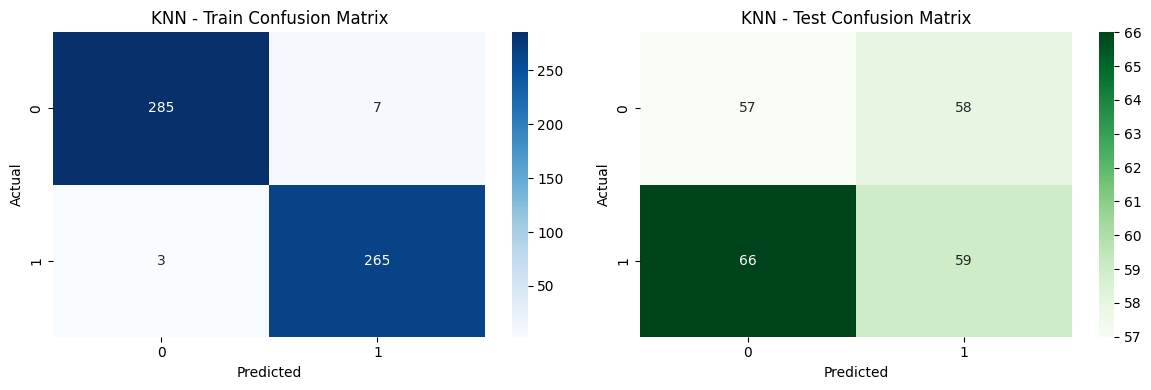

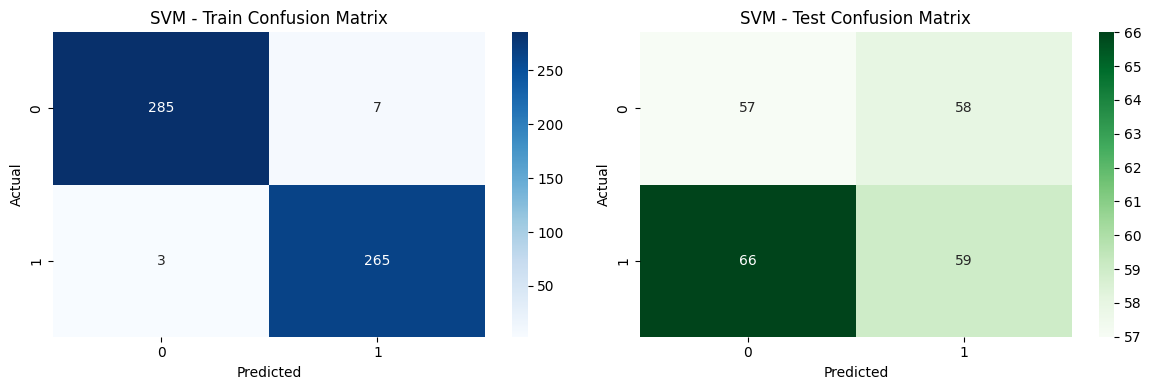

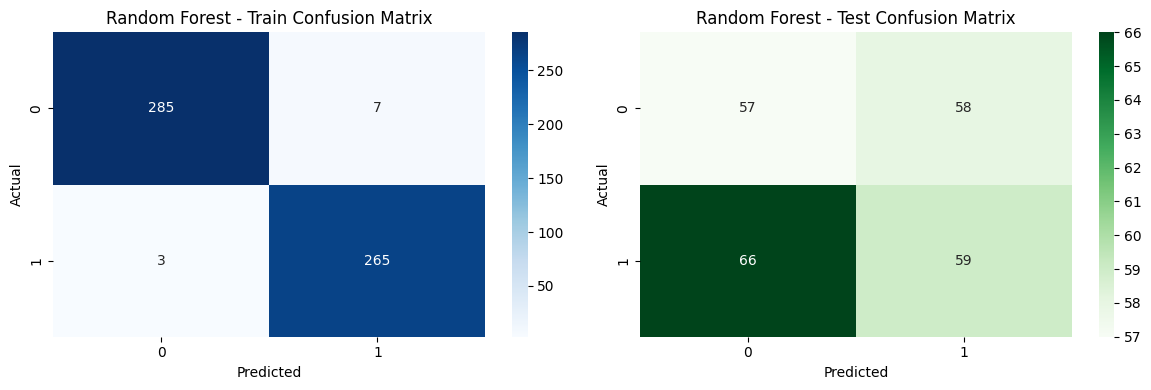


=== SUMMARY OF ALL TUNED MODELS ===
        Model  Train Acc  Test Acc  Train F1  Test F1  Test Precision  Test Recall
   Perceptron   0.982143  0.483333  0.982147 0.483477        0.484695     0.483333
          KNN   0.982143  0.483333  0.982147 0.483477        0.484695     0.483333
          SVM   0.982143  0.483333  0.982147 0.483477        0.484695     0.483333
Random Forest   0.982143  0.483333  0.982147 0.483477        0.484695     0.483333


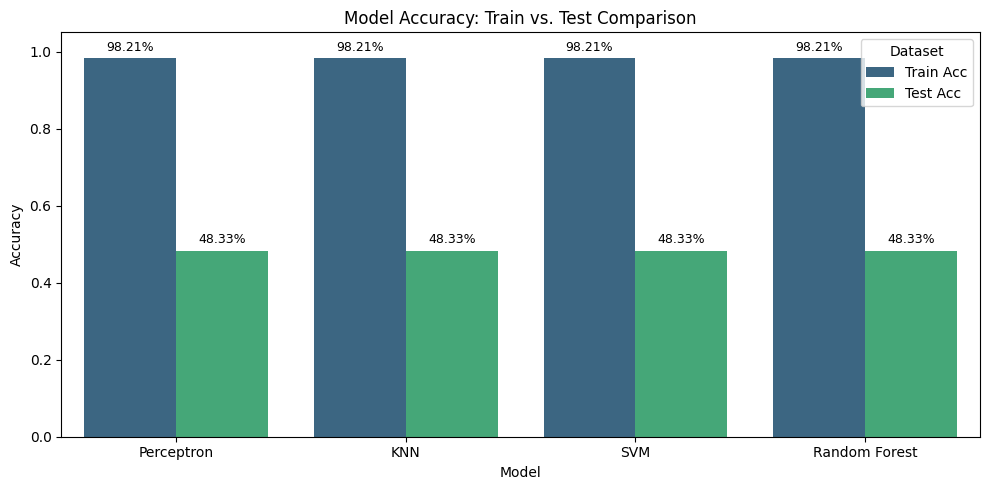

In [ ]:
# =========================================================
# Hyperparameter Tuning (Existing code ends here)
# =========================================================
for name, model in models.items():
    ...
    tuned_models[name] = grid_search.best_estimator_


# =========================================================
# PASTE THE REFACTORED CODE RIGHT HERE AT THE BOTTOM
# =========================================================
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

summary_metrics = []

for name, model in tuned_models.items():
    # Correct predictions using SCALED features
    y_train_pred = model.predict(X_train_scaled)
    y_test_pred = model.predict(X_test_scaled)

    # Store metrics for side-by-side comparison
    summary_metrics.append({
        "Model": name,
        "Train Acc": accuracy_score(y_train, y_train_pred),
        "Test Acc": accuracy_score(y_test, y_test_pred),
        "Train F1": f1_score(y_train, y_train_pred, average='weighted', zero_division=0),
        "Test F1": f1_score(y_test, y_test_pred, average='weighted', zero_division=0),
        "Test Precision": precision_score(y_test, y_test_pred, average='weighted', zero_division=0),
        "Test Recall": recall_score(y_test, y_test_pred, average='weighted', zero_division=0)
    })

    # Visual Evidence: Side-by-side Confusion Matrices
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    cm_train = confusion_matrix(y_train, y_train_pred)
    cm_test = confusion_matrix(y_test, y_test_pred)

    sns.heatmap(cm_train, annot=True, fmt='d', cmap='Blues', ax=axes[0])
    axes[0].set_title(f"{name} - Train Confusion Matrix")
    axes[0].set_xlabel("Predicted")
    axes[0].set_ylabel("Actual")

    sns.heatmap(cm_test, annot=True, fmt='d', cmap='Greens', ax=axes[1])
    axes[1].set_title(f"{name} - Test Confusion Matrix")
    axes[1].set_xlabel("Predicted")
    axes[1].set_ylabel("Actual")

    plt.tight_layout()
    plt.show()

# Table Summary for Q1, Q2, Q3
df_summary = pd.DataFrame(summary_metrics)
print("\n=== SUMMARY OF ALL TUNED MODELS ===")
print(df_summary.to_string(index=False))

# Bar Chart Visualizing Performance / Overfitting (Q3 Evidence)
fig, ax = plt.subplots(figsize=(10, 5))
df_plot = df_summary.melt(id_vars=["Model"], value_vars=["Train Acc", "Test Acc"],
                          var_name="Dataset", value_name="Accuracy")

sns.barplot(data=df_plot, x="Model", y="Accuracy", hue="Dataset", palette="viridis", ax=ax)
ax.set_ylim(0, 1.05)
ax.set_title("Model Accuracy: Train vs. Test Comparison")
for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(f"{p.get_height():.2%}",
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='bottom', fontsize=9, xytext=(0, 3),
                    textcoords='offset points')

plt.tight_layout()
plt.show()

In [ ]:
# Check training label distribution
import pandas as pd

print("--- Train Label Counts ---")
print(pd.Series(y_train).value_counts())

print("\n--- Train Label Percentages ---")
print(pd.Series(y_train).value_counts(normalize=True) * 100)

--- Train Label Counts ---
0    292
1    268
Name: count, dtype: int64

--- Train Label Percentages ---
0    52.142857
1    47.857143
Name: proportion, dtype: float64
